# AMReX Comparison: 3D FFT Poisson Benchmark

This notebook reproduces the existing manufactured-solution benchmark from `codes/cpp/fft_poisson/fft_poisson_3d.cpp` and compares three views of the same problem:

- the exact periodic benchmark field,
- a notebook-side Python FFT solve on the same grid,
- the current C++ solver output in `codes/cpp/fft_poisson/output_3d/solution.vti`.

If a future AMReX export is available as an `.npz` file, the notebook will include it automatically. The AMReX export can optionally carry its own sample coordinates and exact-reference field.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "codes" / "cpp" / "fft_poisson").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


REPO_ROOT = find_repo_root(Path.cwd())
CODES_DIR = REPO_ROOT / "codes"
OUTPUT_DIR = REPO_ROOT / "codes" / "cpp" / "fft_poisson" / "output_3d"
SUMMARY_PATH = OUTPUT_DIR / "run_summary.txt"
SOLUTION_PATH = OUTPUT_DIR / "solution.vti"
AMREX_COMPARE_PATH = REPO_ROOT / "amrex_compare" / "fft_poisson_benchmark.npz"

if str(CODES_DIR) not in sys.path:
    sys.path.insert(0, str(CODES_DIR))

from yee_fdtd_vti import read_vti

plt.style.use("seaborn-v0_8-whitegrid")


## Optional AMReX Input

If you later run an AMReX version of the same benchmark, package a file at `amrex_compare/fft_poisson_benchmark.npz`.

Expected keys:

- required: `phi`
- optional: `rho`, `phi_exact`, `ex`, `ey`, `ez`, `x`, `y`, `z`, `label`

If `x`, `y`, and `z` are present, the notebook evaluates the exact benchmark on those sample coordinates instead of assuming the C++ FFT grid.


In [2]:
def read_summary(path: Path) -> dict[str, str]:
    data = {}
    for line in path.read_text().splitlines():
        if "=" not in line:
            continue
        key, value = line.split("=", 1)
        data[key.strip()] = value.strip()
    return data


def wave_numbers(n: int, length: float) -> np.ndarray:
    return 2.0 * np.pi * np.fft.fftfreq(n, d=length / n)


def relative_l2_error(numerical: np.ndarray, reference: np.ndarray) -> float:
    numerical = np.asarray(numerical, dtype=float)
    reference = np.asarray(reference, dtype=float)
    return float(np.linalg.norm(numerical - reference) / np.linalg.norm(reference))


def relative_vector_l2_error(numerical_components, reference_components) -> float:
    numerical = np.stack([np.asarray(component, dtype=float) for component in numerical_components], axis=-1)
    reference = np.stack([np.asarray(component, dtype=float) for component in reference_components], axis=-1)
    return float(np.linalg.norm(numerical - reference) / np.linalg.norm(reference))


def benchmark_problem(nx: int, ny: int, nz: int, lx: float, ly: float, lz: float, eps0: float) -> dict[str, np.ndarray]:
    x = np.arange(nx, dtype=float) * (lx / nx)
    y = np.arange(ny, dtype=float) * (ly / ny)
    z = np.arange(nz, dtype=float) * (lz / nz)
    return evaluate_exact_on_coords(x, y, z, lx, ly, lz, eps0)


def evaluate_exact_on_coords(x: np.ndarray, y: np.ndarray, z: np.ndarray, lx: float, ly: float, lz: float, eps0: float) -> dict[str, np.ndarray]:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

    phase_x = 2.0 * np.pi * X / lx
    phase_y = 2.0 * np.pi * Y / ly
    phase_z = 2.0 * np.pi * Z / lz

    phi_exact = np.cos(phase_x) * np.cos(phase_y) * np.cos(phase_z)
    prefactor = (2.0 * np.pi / lx) ** 2 + (2.0 * np.pi / ly) ** 2 + (2.0 * np.pi / lz) ** 2
    rho = eps0 * prefactor * phi_exact
    rho = rho - rho.mean()

    ex_exact = (2.0 * np.pi / lx) * np.sin(phase_x) * np.cos(phase_y) * np.cos(phase_z)
    ey_exact = (2.0 * np.pi / ly) * np.cos(phase_x) * np.sin(phase_y) * np.cos(phase_z)
    ez_exact = (2.0 * np.pi / lz) * np.cos(phase_x) * np.cos(phase_y) * np.sin(phase_z)

    return {
        "x": x,
        "y": y,
        "z": z,
        "rho": rho,
        "phi_exact": phi_exact,
        "ex_exact": ex_exact,
        "ey_exact": ey_exact,
        "ez_exact": ez_exact,
    }


def solve_fft_periodic_3d(rho: np.ndarray, lx: float, ly: float, lz: float, eps0: float) -> dict[str, np.ndarray]:
    rho = np.asarray(rho, dtype=float)
    nx, ny, nz = rho.shape

    rho_hat = np.fft.fftn(rho)
    kx = wave_numbers(nx, lx)
    ky = wave_numbers(ny, ly)
    kz = wave_numbers(nz, lz)
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")
    k2 = KX ** 2 + KY ** 2 + KZ ** 2

    phi_hat = np.zeros_like(rho_hat, dtype=complex)
    mask = k2 > 0.0
    phi_hat[mask] = rho_hat[mask] / (eps0 * k2[mask])

    phi = np.fft.ifftn(phi_hat).real
    ex = np.fft.ifftn(-1j * KX * phi_hat).real
    ey = np.fft.ifftn(-1j * KY * phi_hat).real
    ez = np.fft.ifftn(-1j * KZ * phi_hat).real
    residual = np.fft.ifftn(-k2 * phi_hat + rho_hat / eps0).real

    return {
        "phi": phi,
        "rho": rho,
        "ex": ex,
        "ey": ey,
        "ez": ez,
        "residual": residual,
    }


def load_optional_amrex_npz(path: Path):
    if not path.exists():
        return None

    payload = np.load(path, allow_pickle=False)
    data = {key: payload[key] for key in payload.files}
    label = data.get("label")
    if isinstance(label, np.ndarray) and label.shape == ():
        label = str(label.item())
    elif label is None:
        label = "AMReX export"

    result = {"label": label, "path": path}
    for key in ["phi", "rho", "phi_exact", "ex", "ey", "ez", "x", "y", "z"]:
        if key in data:
            result[key] = np.asarray(data[key], dtype=float)
    return result


def metric_row(label: str, phi: np.ndarray, phi_exact: np.ndarray, phi_compare=None, residual=None, field_components=None, field_exact=None):
    row = {
        "solver": label,
        "phi_rel_l2_vs_exact": relative_l2_error(phi, phi_exact),
        "phi_max_abs_vs_exact": float(np.max(np.abs(phi - phi_exact))),
        "phi_rel_l2_vs_cpp": None,
        "phi_max_abs_vs_cpp": None,
        "residual_max_abs": None if residual is None else float(np.max(np.abs(residual))),
        "field_rel_l2_vs_exact": None,
    }

    if phi_compare is not None:
        row["phi_rel_l2_vs_cpp"] = relative_l2_error(phi, phi_compare)
        row["phi_max_abs_vs_cpp"] = float(np.max(np.abs(phi - phi_compare)))

    if field_components is not None and field_exact is not None:
        row["field_rel_l2_vs_exact"] = relative_vector_l2_error(field_components, field_exact)

    return row


def print_metric_table(rows):
    headers = [
        "solver",
        "phi_rel_l2_vs_exact",
        "phi_max_abs_vs_exact",
        "phi_rel_l2_vs_cpp",
        "phi_max_abs_vs_cpp",
        "field_rel_l2_vs_exact",
        "residual_max_abs",
    ]

    table = []
    for row in rows:
        formatted = {}
        for header in headers:
            value = row.get(header)
            if header == "solver":
                formatted[header] = str(value)
            elif value is None:
                formatted[header] = "-"
            else:
                formatted[header] = f"{value:.3e}"
        table.append(formatted)

    widths = {header: max(len(header), *(len(row[header]) for row in table)) for header in headers}
    header_line = " | ".join(header.ljust(widths[header]) for header in headers)
    separator = "-+-".join("-" * widths[header] for header in headers)
    print(header_line)
    print(separator)
    for row in table:
        print(" | ".join(row[header].ljust(widths[header]) for header in headers))


In [3]:
summary = read_summary(SUMMARY_PATH)
if summary.get("scenario") != "benchmark":
    raise ValueError(
        "This notebook expects the existing C++ output to be the manufactured benchmark. "
        "Rerun codes/cpp/fft_poisson/fft_poisson_3d --case benchmark if needed."
    )

nx = int(summary["nx"])
ny = int(summary["ny"])
nz = int(summary["nz"])
lx = float(summary["lx"])
ly = float(summary["ly"])
lz = float(summary["lz"])
eps0 = float(summary["eps0"])

benchmark = benchmark_problem(nx, ny, nz, lx, ly, lz, eps0)
python_fft = solve_fft_periodic_3d(benchmark["rho"], lx, ly, lz, eps0)

cpp_grid = read_vti(SOLUTION_PATH)
cpp_fields = {
    "phi": cpp_grid.point_data["phi"],
    "rho": cpp_grid.point_data["rho"],
    "ex": cpp_grid.point_data["E"][..., 0],
    "ey": cpp_grid.point_data["E"][..., 1],
    "ez": cpp_grid.point_data["E"][..., 2],
}

amrex_fields = load_optional_amrex_npz(AMREX_COMPARE_PATH)
amrex_reference = None
amrex_plot_extent = None
amrex_compare_target = None

metric_rows = [
    metric_row(
        "Python FFT reproduction",
        python_fft["phi"],
        benchmark["phi_exact"],
        phi_compare=cpp_fields["phi"],
        residual=python_fft["residual"],
        field_components=(python_fft["ex"], python_fft["ey"], python_fft["ez"]),
        field_exact=(benchmark["ex_exact"], benchmark["ey_exact"], benchmark["ez_exact"]),
    ),
    metric_row(
        "Current C++ FFT output",
        cpp_fields["phi"],
        benchmark["phi_exact"],
        phi_compare=cpp_fields["phi"],
        field_components=(cpp_fields["ex"], cpp_fields["ey"], cpp_fields["ez"]),
        field_exact=(benchmark["ex_exact"], benchmark["ey_exact"], benchmark["ez_exact"]),
    ),
]

if amrex_fields is not None:
    if all(key in amrex_fields for key in ["x", "y", "z"]):
        amrex_reference = evaluate_exact_on_coords(amrex_fields["x"], amrex_fields["y"], amrex_fields["z"], lx, ly, lz, eps0)
        amrex_plot_extent = (
            float(amrex_fields["x"][0]),
            float(amrex_fields["x"][-1]),
            float(amrex_fields["y"][0]),
            float(amrex_fields["y"][-1]),
        )
    elif "phi_exact" in amrex_fields:
        amrex_reference = {"phi_exact": amrex_fields["phi_exact"]}
        amrex_plot_extent = (0.0, lx, 0.0, ly)
    else:
        amrex_reference = {"phi_exact": benchmark["phi_exact"]}
        amrex_plot_extent = (0.0, lx, 0.0, ly)
        if amrex_fields["phi"].shape == cpp_fields["phi"].shape:
            amrex_compare_target = cpp_fields["phi"]

    amrex_components = None
    amrex_field_exact = None
    if all(key in amrex_fields for key in ["ex", "ey", "ez"]):
        amrex_components = (amrex_fields["ex"], amrex_fields["ey"], amrex_fields["ez"])
    if amrex_reference is not None and all(key in amrex_reference for key in ["ex_exact", "ey_exact", "ez_exact"]):
        amrex_field_exact = (amrex_reference["ex_exact"], amrex_reference["ey_exact"], amrex_reference["ez_exact"])

    metric_rows.append(
        metric_row(
            str(amrex_fields["label"]),
            amrex_fields["phi"],
            amrex_reference["phi_exact"],
            phi_compare=amrex_compare_target,
            field_components=amrex_components,
            field_exact=amrex_field_exact,
        )
    )

print(f"Loaded summary: {SUMMARY_PATH}")
print(f"Loaded C++ field file: {SOLUTION_PATH}")
print(f"Grid shape: {(nx, ny, nz)}")
print(f"Domain lengths: {(lx, ly, lz)}")
if amrex_fields is None:
    print("AMReX compare file not found; skipping AMReX metrics for now.")
else:
    print(f"Loaded AMReX compare file: {amrex_fields['path']}")

print()
print_metric_table(metric_rows)


Loaded summary: /Users/dajuarez4/Computational-Electrodynamics-/codes/cpp/fft_poisson/output_3d/run_summary.txt
Loaded C++ field file: /Users/dajuarez4/Computational-Electrodynamics-/codes/cpp/fft_poisson/output_3d/solution.vti
Grid shape: (64, 64, 64)
Domain lengths: (1.0, 1.0, 1.0)
Loaded AMReX compare file: /Users/dajuarez4/Computational-Electrodynamics-/amrex_compare/fft_poisson_benchmark.npz

solver                  | phi_rel_l2_vs_exact | phi_max_abs_vs_exact | phi_rel_l2_vs_cpp | phi_max_abs_vs_cpp | field_rel_l2_vs_exact | residual_max_abs
------------------------+---------------------+----------------------+-------------------+--------------------+-----------------------+-----------------
Python FFT reproduction | 4.180e-16           | 9.992e-16            | 2.116e-15         | 3.664e-15          | 4.319e-16             | 1.244e-14       
Current C++ FFT output  | 2.316e-15           | 3.997e-15            | 0.000e+00         | 0.000e+00          | 2.285e-15             | -   

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "codes" / "cpp" / "fft_poisson").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


REPO_ROOT = find_repo_root(Path.cwd())
CODES_DIR = REPO_ROOT / "codes"
OUTPUT_DIR = REPO_ROOT / "codes" / "cpp" / "fft_poisson" / "output_3d"
SUMMARY_PATH = OUTPUT_DIR / "run_summary.txt"
SOLUTION_PATH = OUTPUT_DIR / "solution.vti"
AMREX_COMPARE_PATH = REPO_ROOT / "amrex_compare" / "fft_poisson_benchmark.npz"

if str(CODES_DIR) not in sys.path:
    sys.path.insert(0, str(CODES_DIR))

from yee_fdtd_vti import read_vti

plt.style.use("seaborn-v0_8-whitegrid")


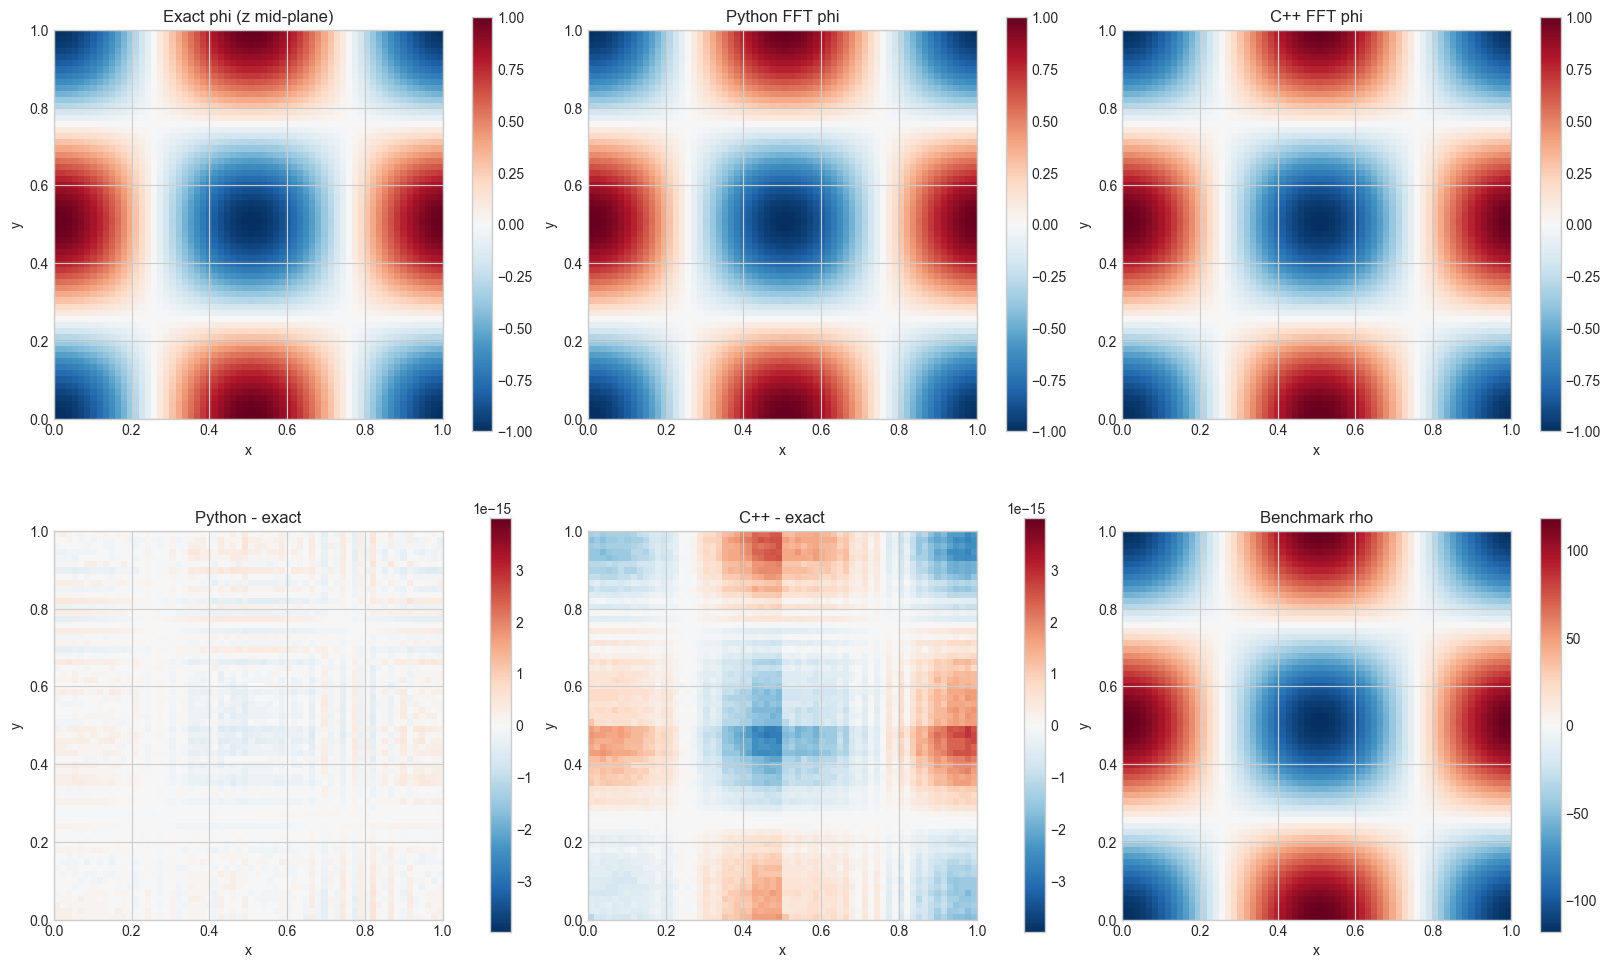

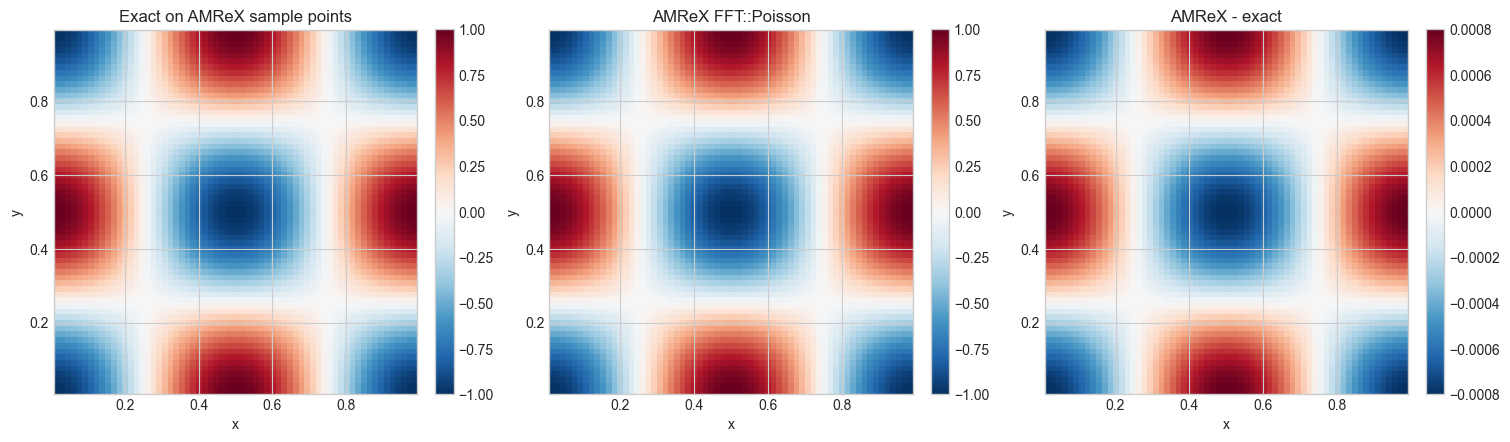

In [4]:
slice_index = nz // 2
extent = (0.0, lx, 0.0, ly)
phi_norm = TwoSlopeNorm(vcenter=0.0, vmin=-1.0, vmax=1.0)
rho_max = float(np.max(np.abs(benchmark["rho"])))
diff_python = python_fft["phi"] - benchmark["phi_exact"]
diff_cpp = cpp_fields["phi"] - benchmark["phi_exact"]
diff_max = max(float(np.max(np.abs(diff_python))), float(np.max(np.abs(diff_cpp))))
diff_norm = TwoSlopeNorm(vcenter=0.0, vmin=-diff_max, vmax=diff_max)

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)

panels = [
    (axes[0, 0], benchmark["phi_exact"][..., slice_index], "Exact phi (z mid-plane)", "RdBu_r", phi_norm),
    (axes[0, 1], python_fft["phi"][..., slice_index], "Python FFT phi", "RdBu_r", phi_norm),
    (axes[0, 2], cpp_fields["phi"][..., slice_index], "C++ FFT phi", "RdBu_r", phi_norm),
    (axes[1, 0], diff_python[..., slice_index], "Python - exact", "RdBu_r", diff_norm),
    (axes[1, 1], diff_cpp[..., slice_index], "C++ - exact", "RdBu_r", diff_norm),
    (axes[1, 2], benchmark["rho"][..., slice_index], "Benchmark rho", "RdBu_r", TwoSlopeNorm(vcenter=0.0, vmin=-rho_max, vmax=rho_max)),
]

for ax, image, title, cmap, norm in panels:
    im = ax.imshow(image.T, origin="lower", extent=extent, cmap=cmap, norm=norm, aspect="equal")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, shrink=0.85)

plt.show()

if amrex_fields is not None:
    amrex_slice_index = amrex_fields["phi"].shape[2] // 2
    amrex_diff_exact = amrex_fields["phi"] - amrex_reference["phi_exact"]
    amrex_diff_max = float(np.max(np.abs(amrex_diff_exact)))
    amrex_diff_norm = TwoSlopeNorm(vcenter=0.0, vmin=-amrex_diff_max, vmax=amrex_diff_max)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
    panels = [
        (axes[0], amrex_reference["phi_exact"][..., amrex_slice_index], "Exact on AMReX sample points", "RdBu_r", phi_norm),
        (axes[1], amrex_fields["phi"][..., amrex_slice_index], str(amrex_fields["label"]), "RdBu_r", phi_norm),
        (axes[2], amrex_diff_exact[..., amrex_slice_index], "AMReX - exact", "RdBu_r", amrex_diff_norm),
    ]

    for ax, image, title, cmap, norm in panels:
        im = ax.imshow(image.T, origin="lower", extent=amrex_plot_extent, cmap=cmap, norm=norm, aspect="equal")
        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        plt.colorbar(im, ax=ax, shrink=0.85)

    plt.show()


## Next Step for a Real AMReX Comparison

To keep the comparison fair, package the AMReX solution together with either its exact field on the same sample locations or the sample coordinates themselves.

A practical first pass is:

1. solve the same periodic benchmark in AMReX,
2. save `phi` and the sample coordinates `x`, `y`, `z`,
3. package those arrays into `amrex_compare/fft_poisson_benchmark.npz`,
4. rerun this notebook and compare the AMReX result against the exact field evaluated on the same points.

That avoids mixing nodal and cell-centered sampling in a misleading way.
